In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_squared_error,r2_score
from math import sqrt
from sklearn.preprocessing import StandardScaler


In [4]:
df=pd.read_csv('Height_Weight.csv')

In [5]:
df.head()

,id,gender,weight,height
0,29,F,39,157
1,182,F,43,154
2,130,F,44,157
3,104,F,45,163
4,128,F,45,157


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      199 non-null    int64 
 1   gender  199 non-null    object
 2   weight  199 non-null    int64 
 3   height  199 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.3+ KB


In [7]:
df.describe()

,id,weight,height
count,199.000000,199.000000,199.000000
mean,100.944724,65.195980,170.587940
std,57.681571,13.008031,8.948848
min,1.000000,39.000000,148.000000
25%,51.500000,55.000000,164.000000
50%,101.000000,63.000000,170.000000
75%,150.500000,73.500000,177.500000
max,200.000000,103.000000,197.000000


In [8]:
df.drop(['id'],axis=1,inplace=True)

In [9]:
df.head()

,gender,weight,height
0,F,39,157
1,F,43,154
2,F,44,157
3,F,45,163
4,F,45,157


In [10]:
df.isnull().sum()

gender    0
weight    0
height    0
dtype: int64

In [11]:
df['gender'].value_counts()

gender
F    111
M     88
Name: count, dtype: int64

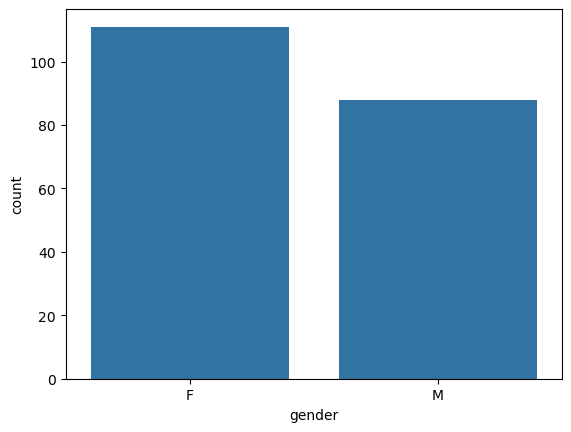

In [12]:
sns.countplot(x='gender',data=df)
plt.show()

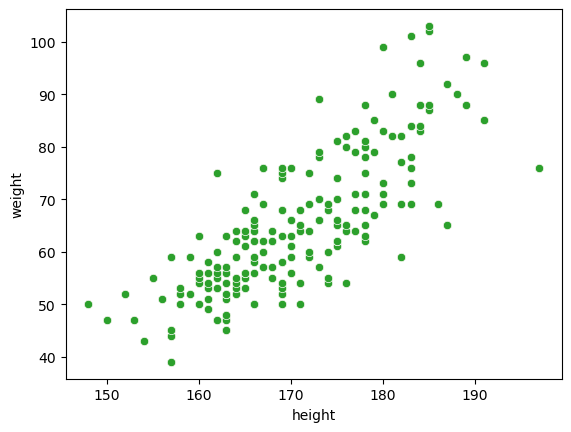

In [16]:
sns.scatterplot(x=df['height'],y=df['weight'])
plt.show()

In [17]:
df_dummies =pd.get_dummies(df['gender'],drop_first=True).astype(int)
df_dummies

,M
0,0
1,0
2,0
3,0
4,0
...,...
194,1
195,1
196,1
197,1


In [20]:
#Combine Columnwise,appending of columns
df_combine = pd.concat([df,df_dummies],axis=1)
df_combine.head()

,gender,weight,height,M
0,F,39,157,0
1,F,43,154,0
2,F,44,157,0
3,F,45,163,0
4,F,45,157,0


In [22]:
df_combine.drop(columns=['gender'],inplace=True)
df_combine.head()

,weight,height,M
0,39,157,0
1,43,154,0
2,44,157,0
3,45,163,0
4,45,157,0


In [23]:
#Finding the correlation coefficient between weight and Height
corr_matrix = df[['height','weight']].corr()
corr_matrix

,height,weight
height,1.000000,0.782438
weight,0.782438,1.000000


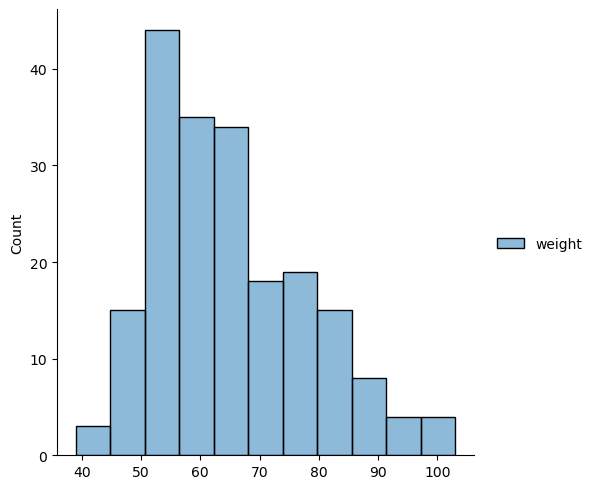

In [28]:
#Distribution plot for weight
sns.displot(df_combine[['weight']],kind='hist')
plt.show()

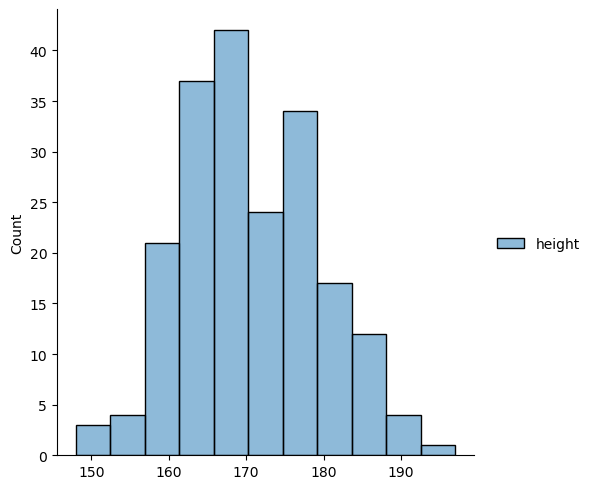

In [31]:
#Disribution plot for height
sns.displot(df_combine[['height']],kind='hist')
plt.show()

In [32]:
#skew in the distribution of height column
df_combine['height'].skew()

0.2129090698591845

In [33]:
#skew in the distribution of weight column
df_combine['weight'].skew()

0.7449402052268245

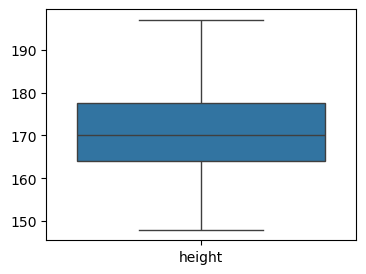

In [38]:
#outlier Detection of height column
plt.figure(figsize=(4,3))
sns.boxplot(df[['height']])
plt.show()

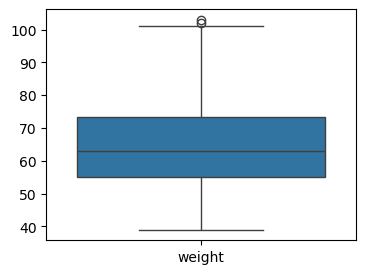

In [39]:
#outlier Detection of height column
plt.figure(figsize=(4,3))
sns.boxplot(df[['weight']])
plt.show()

In [44]:
#putting feature variable to x
X=df_combine.drop('weight',axis=1)
X.head()

,height,M
0,157,0
1,154,0
2,157,0
3,163,0
4,157,0


In [45]:
#putting dependent variable in y
Y=df_combine['weight']
Y.head()

0    39
1    43
2    44
3    45
4    45
Name: weight, dtype: int64

In [49]:
#Split the Data
X_train,X_test,Y_train,Y_test =train_test_split(X,Y,train_size=0.7,random_state=12)

In [50]:
X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

((139, 2), (139,), (60, 2), (60,))

In [51]:
#Performing Linear Regression
lm=LinearRegression()

In [52]:
lm.fit(X_train,Y_train)

LinearRegression()

In [53]:
print(lm.intercept_)

-77.90658193188455


In [54]:
print(lm.coef_)

[0.82001155 7.9819506 ]


In [58]:
Y_pred_test =lm.predict(X_test)

In [59]:
print(Y_pred_test)

[80.13748194 58.21533502 59.85535812 76.85743575 58.21533502 55.75530038
 77.67744729 71.93736646 54.93528883 60.67536967 54.93528883 61.49538122
 82.59751658 43.45512716 51.65524264 67.01729717 84.23753968 63.13540431
 75.21741265 59.03534657 54.93528883 76.0374242  57.39532348 55.75530038
 76.85743575 67.83730872 81.77750503 56.57531193 76.0374242  76.0374242
 75.21741265 76.0374242  73.57738955 57.39532348 69.47733181 48.37519645
 55.75530038 59.85535812 61.49538122 54.93528883 53.29526574 68.65732027
 71.93736646 58.21533502 55.75530038 56.57531193 52.47525419 45.09515026
 66.4154505  77.67744729 91.61764361 67.83730872 85.05755122 57.39532348
 62.31539276 60.67536967 85.05755122 58.21533502 47.5551849  86.69757432]


In [60]:
Y_pred_train =lm.predict(X_train)

In [62]:
print(Y_pred_train)

[71.11735491 76.0374242  55.75530038 64.77542741 54.11527728 77.67744729
 51.65524264 53.29526574 54.93528883 59.85535812 80.95749349 65.37727407
 53.29526574 76.0374242  54.93528883 71.93736646 55.75530038 59.03534657
 59.85535812 60.67536967 78.49745884 71.93736646 74.3974011  72.75737801
 52.47525419 73.57738955 81.77750503 77.67744729 60.67536967 50.83523109
 63.13540431 86.69757432 54.11527728 49.195208   62.31539276 78.49745884
 57.39532348 73.57738955 60.67536967 75.21741265 76.85743575 54.93528883
 73.57738955 64.77542741 81.77750503 50.83523109 54.11527728 80.95749349
 74.3974011  55.75530038 57.39532348 58.21533502 83.41752813 67.01729717
 76.0374242  68.65732027 60.67536967 70.29734336 57.39532348 68.65732027
 57.39532348 54.11527728 69.47733181 68.65732027 59.03534657 54.93528883
 76.0374242  56.57531193 58.21533502 50.83523109 77.67744729 71.11735491
 80.95749349 65.59543895 83.41752813 73.57738955 76.0374242  58.21533502
 54.11527728 63.95541586 55.75530038 75.21741265 50

In [63]:
mse=mean_squared_error(Y_train,Y_pred_train)
rmse = sqrt(mse)
r2Score = r2_score(Y_train,Y_pred_train)
print("TRAINING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TRAINING METRICS:

MSE: 55.51915613956089
RMSE: 7.451117777861311
R2: 0.6498443861822452


In [65]:
mse=mean_squared_error(Y_test,Y_pred_test)
rmse = sqrt(mse)
r2Score = r2_score(Y_test,Y_pred_test)
print("TESTING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TESTING METRICS:

MSE: 64.254793335574
RMSE: 8.015908765422296
R2: 0.661438222561686


In [66]:
df1=pd.DataFrame({'Actual':Y_test,'Predicited':Y_pred_test})
df1.head()

,Actual,Predicited
148,73,80.137482
11,50,58.215335
92,62,59.855358
124,67,76.857436
93,62,58.215335


In [71]:
#Feature Scaling
Scaler=StandardScaler()
X_train_Scaled=Scaler.fit_transform(X_train)
X_test_Scaled =Scaler.transform(X_test)
print(X_test_Scaled)

[[ 1.47589477  1.11442159]
 [-0.5588423  -0.89732648]
 [-0.31946147 -0.89732648]
 [ 0.9971331   1.11442159]
 [-0.5588423  -0.89732648]
 [-0.91791355 -0.89732648]
 [ 1.11682352  1.11442159]
 [ 0.27899061  1.11442159]
 [-1.03760396 -0.89732648]
 [-0.19977105 -0.89732648]
 [-1.03760396 -0.89732648]
 [-0.08008064 -0.89732648]
 [ 1.83496601  1.11442159]
 [-2.71326978 -0.89732648]
 [-1.51636563 -0.89732648]
 [-0.43915189  1.11442159]
 [ 2.07434685  1.11442159]
 [ 0.15930019 -0.89732648]
 [ 0.75775227  1.11442159]
 [-0.43915189 -0.89732648]
 [-1.03760396 -0.89732648]
 [ 0.87744269  1.11442159]
 [-0.67853272 -0.89732648]
 [-0.91791355 -0.89732648]
 [ 0.9971331   1.11442159]
 [-0.31946147  1.11442159]
 [ 1.7152756   1.11442159]
 [-0.79822313 -0.89732648]
 [ 0.87744269  1.11442159]
 [ 0.87744269  1.11442159]
 [ 0.75775227  1.11442159]
 [ 0.87744269  1.11442159]
 [ 0.51837144  1.11442159]
 [-0.67853272 -0.89732648]
 [-0.08008064  1.11442159]
 [-1.99512729 -0.89732648]
 [-0.91791355 -0.89732648]
 

In [72]:
print("*"*50)
print(X_train_Scaled)

**************************************************
[[ 0.15930019  1.11442159]
 [ 0.87744269  1.11442159]
 [-0.91791355 -0.89732648]
 [ 0.39868103 -0.89732648]
 [-1.15729438 -0.89732648]
 [ 1.11682352  1.11442159]
 [-1.51636563 -0.89732648]
 [-1.2769848  -0.89732648]
 [-1.03760396 -0.89732648]
 [-0.31946147 -0.89732648]
 [ 1.59558518  1.11442159]
 [-0.67853272  1.11442159]
 [-1.2769848  -0.89732648]
 [ 0.87744269  1.11442159]
 [-1.03760396 -0.89732648]
 [ 0.27899061  1.11442159]
 [-0.91791355 -0.89732648]
 [-0.43915189 -0.89732648]
 [-0.31946147 -0.89732648]
 [-0.19977105 -0.89732648]
 [ 1.23651394  1.11442159]
 [ 0.27899061  1.11442159]
 [ 0.63806186  1.11442159]
 [ 0.39868103  1.11442159]
 [-1.39667521 -0.89732648]
 [ 0.51837144  1.11442159]
 [ 1.7152756   1.11442159]
 [ 1.11682352  1.11442159]
 [-0.19977105 -0.89732648]
 [-1.63605604 -0.89732648]
 [ 0.15930019 -0.89732648]
 [ 2.43341809  1.11442159]
 [-1.15729438 -0.89732648]
 [-1.87543687 -0.89732648]
 [ 0.03960978 -0.89732648]
 [ 1

In [73]:
lm.fit(X_train_Scaled,Y_train)

LinearRegression()

In [76]:
Y_pred_train =lm.predict(X_train_Scaled)

In [78]:
mse=mean_squared_error(Y_train,Y_pred_train)
rmse = sqrt(mse)
r2Score = r2_score(Y_train,Y_pred_train)
print("TRAINING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TRAINING METRICS:

MSE: 55.51915613956089
RMSE: 7.451117777861311
R2: 0.6498443861822452


In [79]:
Y_pred_test =lm.predict(X_test_Scaled)

In [80]:
mse=mean_squared_error(Y_test,Y_pred_test)
rmse = sqrt(mse)
r2Score = r2_score(Y_test,Y_pred_test)
print("TESTING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TESTING METRICS:

MSE: 64.254793335574
RMSE: 8.015908765422296
R2: 0.661438222561686


In [81]:
#Ridge
ridge=Ridge()
ridge.fit(X_train_Scaled,Y_train)
Y_pred_ridge=ridge.predict(X_test_Scaled)

In [82]:
mse=mean_squared_error(Y_test,Y_pred_ridge)
rmse = sqrt(mse)
r2Score = r2_score(Y_test,Y_pred_ridge)
print("TESTING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TESTING METRICS:

MSE: 64.22149082150571
RMSE: 8.013831219928813
R2: 0.6616136952038163


In [85]:
#Lasso
lasso=Lasso()
lasso.fit(X_train_Scaled,Y_train)
Y_pred_Lasso=lasso.predict(X_test_Scaled)

In [86]:
mse=mean_squared_error(Y_test,Y_pred_Lasso)
rmse = sqrt(mse)
r2Score = r2_score(Y_test,Y_pred_Lasso)
print("TESTING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TESTING METRICS:

MSE: 65.042813317707
RMSE: 8.064912480474106
R2: 0.6572861051559928


In [87]:
#ElasticNet
Elastic=ElasticNet()
Elastic.fit(X_train_Scaled,Y_train)
Y_pred_Elastic=Elastic.predict(X_test_Scaled)

In [88]:
mse=mean_squared_error(Y_test,Y_pred_Elastic)
rmse = sqrt(mse)
r2Score = r2_score(Y_test,Y_pred_Elastic)
print("TESTING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TESTING METRICS:

MSE: 73.00026596087984
RMSE: 8.544019309486599
R2: 0.6153578820476594


In [91]:
from sklearn.linear_model import SGDRegressor
sg =SGDRegressor()
sg.fit(X_train_Scaled,Y_train)

SGDRegressor()

In [92]:
Y_pred_sg =sg.predict(X_test_Scaled)

In [93]:
mse=mean_squared_error(Y_test,Y_pred_sg)
rmse = sqrt(mse)
r2Score = r2_score(Y_test,Y_pred_sg)
print("TESTING METRICS:\n")
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2Score)

TESTING METRICS:

MSE: 64.21096933718944
RMSE: 8.01317473522133
R2: 0.6616691334403506
